# Implicit function toolbox for geophysics

If we can fit a point data to an Implicit Neural Network, we can operate directly on the Neural Network representation.

In [2]:
%load_ext autoreload
%autoreload 2
# %matplotlib inline


import json
import random
from pathlib import Path

import comet_ml
import colorcet as cc
import harmonica as hm
import matplotlib.pyplot as plt
import numpy as np
# import pyproj
# import rasterio as rio
import scipy
import torch
import verde as vd
import xarray as xr
from torch.utils.data import random_split


import geoinr.batcheddatasets
import geoinr.trainval
from geoinr.batcheddatasets import construct_xyz
from geoinr.batcheddatasets import BatchingDataloader, NCDataset, NoddyDataset
from geoinr.models import Siren
from geoinr.models import get_INR as wire
from geoinr.utils import (
    query_inr, query_inr_batched, plt_inr, plt_cntr, plt_3d,
    plt_sample_locs, plt_kwargs, e_size, load_nc_grid, transect
    )


torch.manual_seed(seed := 0)
random.seed(seed)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = "cuda"

fig_out = Path("figures")
style = "./mpl_styles/paper.mplrc"
plt.style.use(style)

In [3]:
# file_path = Path(r"C:\Users\Public\scratch\Ch3\Ice_Cap.csv")
# dataset = geoinr.batcheddatasets.CSVDataset(
#     file_path, variable="MagF", usecols=("X", "Y", "Height_WGS84", "MagF")
# )
# dataset = dataset.subsample_wesnbt((-0.5, 0.6, -0.5, 0.5, -1, 1))
# train_dataset, val_dataset = random_split(dataset, [0.3, 0.7])
# print(f"{len(train_dataset)=}, {len(val_dataset)=}")


In [ ]:
# Synthetic Data /mnt/win_data/luke/phd
shortname = "noddy"

# noddy_path = Path("/mnt/win_data/luke/data_source/Forward_models_xyz/20-09-04-15-28-12-785467793")
noddy_path = Path(
    "/mnt/win_data/luke/data_source/Noddy_data/noddyverse_train_data/DYKE_FAULT_FOLD/models_by_code/models/DYKE_FAULT_FOLD"
)
dataset = NoddyDataset(noddy_path, "mag", file_limit=300, specific_id=268)
# dataset.subsample_wesnbt((-1, 1, -1, 1, -1, 1))
altitude = 100
cell_size = 80  # target grid cs
# for i in [46,47,84,169,219,268]:
for i in [0]:
    gtt = (
        dataset[:, :]["u"].reshape(200, 200, 1)[:, :, i].fliplr().rot90().flipud()
    )  # get axes right instead of messing around
    gtt = dataset.unnormalise(gtt, "u").numpy()
    fig = plt.figure(figsize=(e_size("1.5"), e_size("1")), constrained_layout=True)
    plt.title("Ground Truth Noddyverse Grid")
    plt.imshow(gtt, cmap=cc.cm.CET_L1, extent=(0, 4000, 0, 4000))
    plt.colorbar(label="nT")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    fig.savefig(fig_out / f"Synthetic fwd model.png", dpi=1000)
    fig.savefig(fig_out / f"Synthetic fwd model.pdf", dpi=1000)

print((fig_out / f"Synthetic fwd model.png").absolute())

if 0:
    # Random sampling
    train_dataset, val_dataset, test_dataset = random_split(dataset, [0.055, 0.945, 0])

else:
    # Line Spacing Split
    from torch.utils.data.dataset import Subset

    line_spacing = 400  # 400
    ls = line_spacing // 20
    print(f"{ls=}")
    assert ls == line_spacing / 20, "integer only"

    trn_indices = torch.arange(len(dataset))[::ls].tolist()
    trn_indices.extend(
        torch.arange(len(dataset))[199::200].tolist()
    )  # Add perimeter survey line
    train_dataset = Subset(dataset, trn_indices)

    mask = np.ones(len(dataset), bool)
    mask[trn_indices] = 0
    val_indices = torch.arange(len(dataset))[mask]

    # val_indices = [i for i in torch.arange(len(dataset)) if i not in trn_indices]
    val_dataset = Subset(dataset, val_indices)

x, y, im = dataset.xyz[train_dataset.indices].T

if True:
    plt.figure(figsize=(5, 5))
    plt.imshow(gtt, extent=(-1, 1, -1, 1), cmap=cc.cm.CET_L1)
    plt.scatter(x, y, c="r", marker=".", s=1)
    plt.axis("scaled")
    plt.show()

In [4]:
# P864 - Wolfe Creek
# !wget "https://dapds00.nci.org.au/thredds/fileServer/iv65/Geoscience_Australia_Geophysics_Reference_Data_Collection/airborne_geophysics/WA/line/P864/P864-line-magnetic-AWAGS_MAG_2010.nc"
shortname = "P864"
netcdf_path = Path("/mnt/win_data/luke/data_source/P864-line-magnetic-AWAGS_MAG_2010.nc")
dataset = NCDataset(netcdf_path, variable="mag_microLevelled")
# dataset.xyz = dataset.xyz[:69700,:] # Drop tie lines at end of file
# dataset.u = dataset.u[:69700,:]
altitude = 40 # Read dataset.ncd description
cell_size = 10
res = None
# gtt_path = Path("C:/Users/Public/scratch/Ch3/P864-grid-tmi.ers")
train_dataset, val_dataset, test_dataset = random_split(dataset, [0.8, 0.2, 0])


/home/luke/mambaforge/envs/phd/lib/python3.11/site-packages/torch/utils/data/dataset.py:473: UserWarning: Length of split at index 2 is 0. This might result in an empty dataset.
  warnings.warn(


In [5]:
dataset.ncd

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    CreationTime: Sun Dec 15 23:11:52 2019
    CreationMethod: intrepid2netcdf.exe
    IntrepidSourceDataset: ./mag_database_reformat_adjusted/intrepid/GSWA_P864MAG
    median_sample_spacing_m: 5.3
    geospatial_bounds: POLYGON ((127.774883 -19.167250, 127.775190 -19.156111, 127.776843 -19.151728, 127.812499 -19.151806, 127.815741 -19.152477, 127.817157 -19.156252, 127.817040 -19.187409, 127.815768 -19.192270, 127.779354 -19.192388, 127.775891 -19.191653, 127.774435 -19.186447, 127.774883 -19.167250))
    geospatial_lon_max: 127.817009
    geospatial_lat_min: -19.192135
    geospatial_lat_max: -19.152143
    geospatial_lon_min: 127.774902
    geospatial_bounds_crs: GEOGCS["GDA94",
    DATUM["Geocentric_Datum_of_Australia_1994",
        SPHEROID["GRS 1980",6378137,298.257222101,
            AUTHORITY["EPSG","7019"]],
        TOWGS84[0,0,0,0,0,0,0],
        AUTHORITY["EPSG","6283"]],
    PRIMEM["Greenw

In [6]:
# # P1260 Menzies North
# shortname = "P1260"
# altitude = 50
# # https://ecat.ga.gov.au/geonetwork/srv/eng/catalog.search#/metadata/143620
# # line: ! wget "https://dapds00.nci.org.au/thredds/fileServer/iv65/Geoscience_Australia_Geophysics_Reference_Data_Collection/airborne_geophysics/WA/line/P1260/P1260-line-magnetic-AWAGS_MAG_2010.nc"
# # grid: ! wget "https://dapds00.nci.org.au/thredds/fileServer/iv65/Geoscience_Australia_Geophysics_Reference_Data_Collection/airborne_geophysics/WA/grid/P1260/P1260-grid-tmi.nc"

# netcdf_path = Path("/home/luke/ImplicitGeo/data/Ch3/P1260/P1260-line-magnetic-AWAGS_MAG_2010.nc")
# dataset = geoinr.batcheddatasets.NCDataset(netcdf_path, variable="mag_microlevelled")
# ## Subsample full dataset (e.g. remove tie lines at end of file, or decimate)
# dataset.xyz = dataset.xyz[:12132381]
# dataset.u = dataset.u[:12132381]

# # Crop
# gtt_extent = b = [120.52, 120.57, -29.3, -29.25]
# dataset = dataset.subsample_wesnbt((
#               dataset.normalise(b[0], "e"), dataset.normalise(b[1], "e"),
#               dataset.normalise(b[2], "n"), dataset.normalise(b[3], "n"),
#              -1, 1,))

# # Load Reference Grid
# gtt, gtt_extent = load_nc_grid(
#     "/home/luke/ImplicitGeo/data/Ch3/P1260/P1260-grid-tmi.nc", crop=gtt_extent
#     )

In [7]:
print(f"{len(train_dataset) = }, {len(val_dataset) = }")
print(
    f"Percent train split: {(len(train_dataset) / (len(val_dataset) + len(train_dataset))) * 100:0.1f}%"
)
print(f"Dropped {dataset.invalid_points} invalid points")

print(f'Mean Alt: {dataset.unnormalise(dataset.xyz[:, 2], "up").mean().item():.2f}')
print(f'Std Alt: {dataset.unnormalise(dataset.xyz[:, 2], "up").std().item():.2f}')


len(train_dataset) = 61136, len(val_dataset) = 15284
Percent train split: 80.0%
Dropped 0 invalid points
Mean Alt: 39.69
Std Alt: 4.95


In [8]:
# dataset.ncd.variables.keys()
# np.arange(dataset.ncd.variables["lineType"][:].data)
# ((dataset.ncd.variables["line_index"][:]).data)

In [9]:
# plt_kwargs(f"{netcdf_path.stem}", {"extent":gtt_extent, "cmap":cc.cm.CET_L1}, Grid=gtt)

In [10]:
# dataset.plot_variables(
#     # ["mag_tieLevelled", "mag_microLevelled", "mag_awagsLevelled"], s=0.01
#     ["mag_microLevelled"], s=0.01
# )
# # "microlevelling removes low amplitude flight line noise after tie line levelling."
# dataset.plot_variables(["altitude"], s=0.01)

In [11]:
# fig_out.mkdir(exist_ok=True)
# print(fig_out/{shortname}_sample_locs").absolute())

In [12]:
# # Cubic grid dataset samples

# x, y, _ = dataset.xyz[train_dataset.indices].T.numpy()
# altitude = 40

# projection = pyproj.Proj(proj="merc", lat_ts=y.mean())
# x, y = projection(x, y)

# coord = (x, y, altitude * np.ones_like(x))

# # d = 4000
# w, e, s, n = np.array([x.min(), x.max(), y.min(), y.max()], dtype=np.float32)
# cs_fac = 5
# # cs = line_spacing / cs_fac  # Cell size is e.g. 1/4 line spacing
# cs = 20  # Cheat interpolation to same size for comparison

# # x, y, _ = train_dataset[:]["xyz"].T.numpy()
# # x = dataset.unnormalise(x, "e")
# # y = dataset.unnormalise(y, "n")
# # y2  = np.hstack([0, 400, 800, 1200, 1600, 2000, 2400, 2800, 3200, 3600] * 200)

# coordinates = np.meshgrid(
#     np.arange(w, e, step=cs),
#     np.arange(s, n, step=cs),
#     indexing="xy",
# )

# gridder = vd.Cubic()
# gridder = gridder.fit(coordinates=(x, y), data=train_dataset[:]["u"].squeeze().numpy())
# grid = gridder.grid(
#     data_names="forward",
#     coordinates=coordinates,
# )
# grid = np.flipud(grid.get("forward").values.astype(np.float32))
# grid

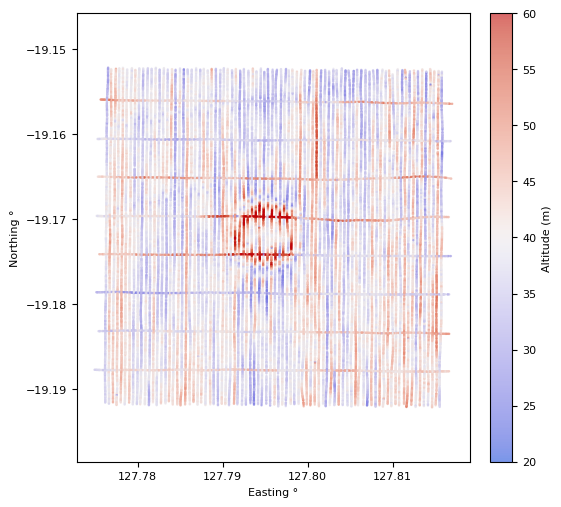

In [51]:
# %matplotlib widget
fig = plt_sample_locs(
    dataset,
    indices=train_dataset.indices,
    # label="mag (nT)",
    unnormalise_fn=dataset.unnormalise,
    # u=dataset.u[train_dataset.indices],
    label="Altitude (m)",
    u=altitude,
)  
fig.savefig(fig_out/f"{shortname}_F6_sample_locs.pdf", dpi=1000)
fig.savefig(fig_out/f"{shortname}_F6_sample_locs.png", dpi=1000)
# %matplotlib inline

In [14]:
train_opts = dict(
    total_epochs=10_000,  # 00,
    batch_size=512_000,  # 2_048_000,  # 1M for 12 GB
    initial_lr=2e-4,
    scheduler="oclr",
    nonlinearity="wire2d",
    hidden_layers=5,
    hidden_features=512,
    weight_floss=0,  # 10,  # .01, #4e-4,  # 1e-3, #1e-4,  # 1e-4,
    weight_rloss=0,  # 1e-3, #1e-4,  # 1e-4,
    rloss_Sigma=2e-2,  # norm width is 2
    n_samples=int(0.01 * dataset.u.shape[0]),  # 10% samples for RLoss
    wire_omega_0=3,  # Best for real data?
    wire_sigma=3,
    # wire_omega_0=1,   # Best for synthetic data
    # wire_sigma=1,
    device=device,
    use_amp=False,
    # gt_tiff=tifffile.imread(gtt_path),
)

train_dataloader = BatchingDataloader(
    train_dataset,
    batch_size=train_opts["batch_size"],
    pin_memory=True,
)

val_dataloader = BatchingDataloader(
    val_dataset,
    batch_size=train_opts["batch_size"],
    pin_memory=True,
)

if train_opts["nonlinearity"] in ["sinusoidal", "siren"]:
    comet_tags = ["SIREN"]
    model = Siren(
        in_features=3,
        out_features=1,
        hidden_features=train_opts["hidden_features"],
        hidden_layers=train_opts["hidden_layers"],
        outermost_linear=True,
    )

elif "wire" in train_opts["nonlinearity"]:
    comet_tags = ["WIRE"]
    model = wire(
        nonlin=train_opts["nonlinearity"],  # "wire2d" | "wire3d"
        in_features=3,
        out_features=1,
        hidden_features=train_opts["hidden_features"],
        hidden_layers=train_opts["hidden_layers"],
        first_omega_0=train_opts["wire_omega_0"],  # first Frequency of sinusoid
        hidden_omega_0=train_opts["wire_omega_0"],  # hidden Frequency of sinusoid
        scale=train_opts["wire_sigma"],  # Sigma of Guassian
    )

f = model.to(device, non_blocking=True)

exp = geoinr.trainval.Exp(
    f,
    {"train": train_dataloader, "val": val_dataloader},
    train_opts,
)
inr = exp.train_inr()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/lukesmithgeo/geoinr/fffa8c033c134f90862800c1d392d426



Training:   0%|          | 0/10000 [00:00<?, ?epoch/s]

COMET INFO: Please wait for metadata to finish uploading (timeout is 3600 seconds)


Total steps: 10000


In [15]:
exp.exp.end()

In [16]:
# loss_json = Path(
#     "/mnt/win_data/luke/phd/ch3/ImplicitGeo/Train Loss MSE,Val Loss MSE VS step_chart_data.json"
# ).read_text()
# jtrain, jval, jtype, jname = json.loads(loss_json)
# # jtrain, jval = exp.loss_curves
# plt.figure(constrained_layout=True, figsize=(e_size("single"), e_size(60)), dpi=1000)
# # plt.title("Convergence")
# plt.yscale("log")
# plt.xlabel("Epoch")
# plt.ylabel("MSE")
# plt.plot(jtrain["x"], jtrain["y"], "-", linewidth=0.8, c="0.2", label="Train")
# plt.plot(jval["x"], jval["y"], "--", linewidth=0.8, c="0.3", label="Validation")
# plt.legend()
# plt.savefig(fig_out/f"{shortname}_F1_loss_plot.png", dpi=1000)
# plt.savefig(fig_out/f"{shortname}_F1_loss_plot.pdf", dpi=1000)
# print((fig_out/f"{shortname}_F1_loss_plot.png").absolute())

In [17]:
# import rasterio
# with rasterio.open(gtt_path) as src:
#     gtt = src.read(1)
#     gtt_extent = src.bounds

In [18]:
normalise_fn = dataset.normalise
unnormalise_fn = dataset.unnormalise

# shape = (gtt.shape[1], gtt.shape[0], 3)
# b = gtt_extent

## Noddyverse
# res = 50 # OR spec cell size
# # res = 200
# b = [0, 4000, 0, 4000]
# altitude = 100  # dataset.ncd.variables["altitude"][:].mean()

## P864
res = 445 # OR spec cell size
cs = 80

b = [*dataset.var_ranges["e"], *dataset.var_ranges["n"]]
extent = [
    unnormalise_fn(dataset.extent[0], "e"),
    unnormalise_fn(dataset.extent[1], "e"),
    unnormalise_fn(dataset.extent[2], "n"),
    unnormalise_fn(dataset.extent[3], "n"),
]

shape = (res, res, 1)
z_mod = normalise_fn(altitude, "up")
# ax_args = dict(cmap=cc.cm.CET_L1, vmin=-70, vmax=-55)
z_vec = normalise_fn(torch.linspace(altitude, 100, steps=shape[2]), "up")
# z_vec = torch.tensor([z_mod])

u = query_inr_batched(
    inr,
    shape=shape,
    chunksize=1_024_000,
    x_vec=normalise_fn(torch.linspace(b[0], b[1], steps=shape[0]), "e"),
    y_vec=normalise_fn(torch.linspace(b[2], b[3], steps=shape[1]), "n"),
    # x_vec=normalise_fn(torch.arange(b[0], cs, b[1]), "e"),
    # y_vec=normalise_fn(torch.arange(b[2], cs, b[3]), "n"),
    # z_vec=torch.tensor([9291], dtype=torch.float32), #z_vec,
    z_mod=z_mod,
)

u = unnormalise_fn(u, "u")
std = u[1].std()
print(f"{altitude = :.2f}, {z_mod = :.2f}")
print(f"{u.mean() = :.2f}, {u.std() = :.2f}")

altitude = 40.00, z_mod = -0.47
u.mean() = -63.87, u.std() = 3.37


In [19]:
# # cs_fac = 5
# # cs = line_spacing / cs_fac  # Cell size is e.g. 1/4 line spacing
# # cs = 80  # Cheat interpolation to same size for comparison
# # res = 
# # res = 4000 // cs

x, y, _ = train_dataset[:]["xyz"].T.numpy()
# # x = dataset.unnormalise(x, "e") # disable to cheat normalised "projection" for interoperability
# # y = dataset.unnormalise(y, "n")
# # y2  = np.hstack([0, 400, 800, 1200, 1600, 2000, 2400, 2800, 3200, 3600] * 200)

# Synthetic (Nominal projected coord sys)
# d = 4000
w, e, s, n = np.array([-1, 1, -1, 1], dtype=np.float32)
grid_coords = np.meshgrid(
    # np.arange(w, e, step=cs),
    # np.arange(s, n, step=cs),
    np.linspace(w, e, res),
    np.linspace(s, n, res),
    indexing="xy",
)

data = dataset.unnormalise(train_dataset[:]["u"].squeeze().numpy(), "u")


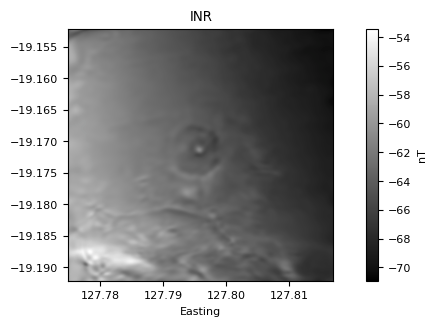

/mnt/win_data/luke/phd/ch3/ImplicitGeo/figures/P864_grid_comparison_40m.png


In [20]:
ax_args = dict(cmap=cc.cm.CET_L1)
for i, z_slice in enumerate(np.expand_dims(u, 2).transpose(2, 0, 1)):  # Iter through *zxy* slices
# for i, z_slice in enumerate(u.transpose(2, 0, 1)):  # Iter through *zxy* slices
    # altitude = unnormalise_fn(z_vec[i], "up")
    fig = plt_inr(
        z_slice,
        extent=b,
        suffix=f"",
        # suffix=f", Altitude: {unnormalise_fn(z_mod, 'up')} m",
        ax_args=ax_args,
        # gt_grid=rio.open("/home/luke/ImplicitGeo/data/Ch3/wolfcreek_mag_microLevelled_bidir_30m.ers").read()[0,:,:], #,ref_grid,
        # gt_grid=grid,
        # gt_grid=cubic_grid,
        # cropping=(0, shape[1], 0, shape[0]),
        # cropping=(100, 400, 50, 350),  # cells in from n s w e, use equal in axes
        _vmin=-5,
        _vmax=5,
        residual=False,
        figsize=(e_size("full"), e_size(80)),
        dpi=100,
    )
    plt.show()

    # fig.savefig(fig_out / "test.png")
    fig.savefig(fig_out / f"{shortname}_grid_comparison_{int(altitude)}m.png", dpi=1000)
    fig.savefig(fig_out / f"{shortname}_grid_comparison_{int(altitude)}m.pdf", dpi=1000)
    
    print((fig_out / f"{shortname}_grid_comparison_{int(altitude)}m.png").absolute())

In [21]:
# Reprojecting for eq. sources
easting = dataset.unnormalise(x, "e") 
northing = dataset.unnormalise(y, "n")

# Real data:
import pyproj
projection = pyproj.Proj("EPSG:32751")
easting, northing = projection(easting, northing)
#

coordinates = (easting, northing, altitude * np.ones_like(x))
xy_region = vd.get_region((easting, northing))
# print(f"x resolution {(xy_region[1] - xy_region[0]) / res:0.2f} m")
# print(f"y resolution {(xy_region[3] - xy_region[2]) / res:0.2f} m")

grid_coords = vd.grid_coordinates(
    region=xy_region,
    # spacing=cell_size,
    adjust="spacing",
    shape=(res,res),
    extra_coords=altitude,  # Z elevation of predicted points (continuation)
)

# Real
eqs = hm.EquivalentSourcesGB(depth=200, damping=1e-2, block_size=20, window_size=2000)
# ## Synthetic
# eqs = hm.EquivalentSourcesGB(damping=10e-2, depth=360) #, block_size=None, window_size="default", parallel=True)

print(f"{eqs.estimate_required_memory(coordinates) / 1_000_000_000:0.2f} GB RAM required")

0.46 GB RAM required


In [22]:
eqs.fit(coordinates, data)
eq_source_grid = np.flipud(eqs.grid(grid_coords, data_names=["magnetic"]).to_array().squeeze())
# plt.imshow(eq_source_grid, cmap=cc.cm.CET_L1, vmin=-70, vmax=-50)

In [23]:
cbc = vd.Cubic()
cbc = cbc.fit(coordinates, data)
cubic_grid = np.flipud(cbc.grid(coordinates=grid_coords, data_names=["magnetic"]).to_array().squeeze())
# plt.imshow(cubic_grid, cmap=cc.cm.CET_L1, interpolation="Nearest")

/mnt/win_data/luke/phd/ch3/ImplicitGeo/figures/P864_F7_Comparison_of_Gridding_Methods.png


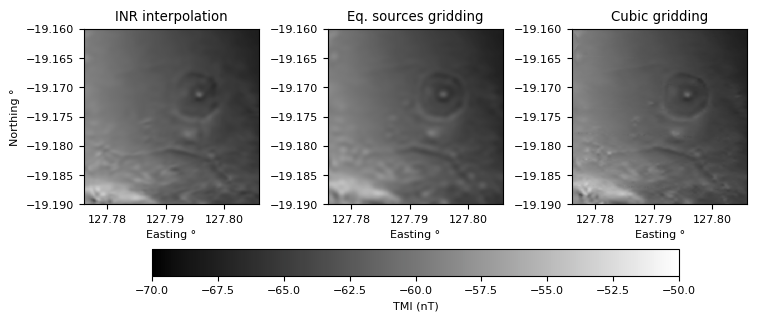

In [41]:
# grid_u = dataset.unnormalise(grid, "u")
# sample_u = dataset.unnormalise(sample, "u")
c0, c1, c2, c3 = (100, -10, 10, -100)

# gttr = scipy.ndimage.zoom(gtt, 0.25, order=3)
# print(f"{gttr.shape=}")

x0, x1, y0, y1 = (0, 3999, 4000 - (8 * 80), 4000 - (8 * 80))  # Synthetic

fig = plt_kwargs(
    ax_args={
        "cmap": cc.cm.CET_L1,
        "vmin": -70,
        "vmax": -50,
        # "vmin": -200,
        # "vmax": 400,
        "extent": extent,
        # "extent": [0, 4000, 0, 4000],
        "interpolation": "Nearest",
        # "interpolation":"Antialiased"
        # "interpolation":"Bicubic"
    },
    suptitle=None,  # "Comparison of Gridding Methods",
    # unit="(m)",
    # shape=(2, 4), # Synthetic
    shape=(1, 3), # Real
    # transect_coords=(x0, x1, y0, y1),
    **{
        "figsize": (e_size("2"), e_size(80)),
        "label": "TMI (nT)",
        # "std": 60,
        "xlim": (127.776, 127.806),
        "ylim": (-19.19, -19.16),
        # "Reference grid (GT)": grid[c0:c1, c2:c3],
        # "Ground truth grid (GT)": gtt,  # [c0:c1, c2:c3],
        "INR interpolation": z_slice,  # [c0:c1, c2:c3],
        "Eq. sources gridding": eq_source_grid,  # [c0:c1, c2:c3],
        "Cubic gridding": cubic_grid,  # [c0:c1, c2:c3],
        # "None": "None",
        # "Resized GT (GT*)": gttr,  # [c0:c1, c2:c3],
        # "Residual:\nGT* - INR interpolation": (gttr - z_slice),  #
        # "Residual:\nGT* - Eq. sources grid": (gttr - eq_source_grid),  #
        # "Residual:\nGT* - Cubic grid": (gttr - cubic_grid),  #
        # "Residual:\nGT - INR interpolation": (cubic_grid[c0:c1, c2:c3] - z_slice[c0:c1,c c2:c3]),
        # "Residual:\nGT - Eq. sources grid": (cubic_grid[c0:c1, c2:c3] - eq_source_grid[c0:c1, c2:c3]),
    },
    # geo_dudz=geo_dudz,
)

fig.savefig(fig_out / f"{shortname}_F7_Comparison_of_Gridding_Methods.png", dpi=1000)
fig.savefig(fig_out / f"{shortname}_F7_Comparison_of_Gridding_Methods.pdf", dpi=1000)
print((fig_out / f"{shortname}_F7_Comparison_of_Gridding_Methods.png").absolute())

In [ ]:
figname = shortname
ims = [gtt, z_slice[:50, :50], eq_source_grid[:50, :50], cubic_grid[:50, :50]]  # gtt
labels = ["GT", "INR", "Eq. Sources", "Bicubic"]  # "Ground Truth",

def plt_transect_space():
    cell_size = 80
    # extent
    scale = 1  # Original shape vs gridded shape
    scalef = 1

    # x0, x1, y0, y1 = (100, 3800, 500, 500)  # Synthetic
    x0, x1, y0, y1 = (50, 3850, 640, 640)  # Synthetic
    transect_coords = x0, x1, y0, y1

    # x0, x1, y0, y1 = (50, 3850, 3250, 3250)  # Synthetic
    # x0, x1, y0, y1 = (50, 3850, 3000, 3100)  # Synthetic
    # x0, x1, y0, y1 = (50, 3850, 3500, 3500)  # Synthetic
    # x0, x1, y0, y1 = (2350, 2350, 100, 3800)  # Synthetic
    # x0, x1, y0, y1 = (127.784, 127.784, -19.191, -19.153)  # Real
    # nsamples = max(res, 100)  # x1 - x0
    nsamples = 200  # x1 - x0

    transect_coords = [
        # x0,
        # x1,
        # y0,
        # y1,
        dataset.normalise(x0, "e") * res,
        dataset.normalise(x1, "e") * res,
        dataset.normalise(y0, "n") * res,
        dataset.normalise(y1, "n") * res,
    ]
    # x0, x1, y0, y1 = transect
    x0p, x1p, y0p, y1p = (
        (((np.array(transect_coords) / res) + 1) / 2 * res).round().astype(int)
    )  # Convert to approx pixel indices

    transect_coords = x0, x1, y0, y1

    styles = ["k-", "g-", "b-", "r-"]

    cims=[]
    fig, axes = plt.subplots(1, len(ims), figsize=(15, 5))
    axes[0].set_ylabel("Northing")
    for ax, im, style in zip(axes, ims, styles):
        im = np.flipud(im)
        ax.set_xlabel("Easting")
        cim = ax.imshow(np.flipud(im), cmap=cc.cm.CET_L1, extent=extent),
        cims.append(cim)
        ax.plot([x0, x1], [y0, y1], style)
        ax.annotate(
            "A",
            (x0, y0),
            c=style[0],
            backgroundcolor=("gray", 0.5),
            xytext=(0.25, 1),
            textcoords="offset fontsize",
        )
        ax.annotate(
            "A'",
            (x1, y1),
            c=style[0],
            backgroundcolor=("gray", 0.5),
            xytext=(-0.75, 1),
            textcoords="offset fontsize",
        )
    fig.colorbar(cim[0], ax=axes, orientation="horizontal", shrink=0.3, aspect=10)
    # fig.savefig(fig_out / f"{shortname}_F3_transect.png", dpi=1000)
    # fig.savefig(fig_out / f"{shortname}_F3_transect.pdf", dpi=1000)


    # print((fig_out / f"{shortname}_F3_transect.pdf").absolute())

    return NotImplementedError

# plt_transect_space() # We don't actually use the function in this cell

#     # This is tricky - transect specified in axes units, but we deal in pixel units here.
#     # ticks: np.linspace(0, lr_dim * cell_size, 5)
#     # extent: (0, lr_dim * cell_size, 0, lr_dim * cell_size)

In [ ]:
# utils.transect
fig = transect(ims, gtt, indice=8)
fig.savefig(fig_out / f"{shortname}_F3_transectmap.png", dpi=1000)
fig.savefig(fig_out / f"{shortname}_F3_transectmap.pdf", dpi=1000)

print((fig_out / f"{shortname}_F3_transectmap.png").absolute())

# calculate IoU (or min / max metric for quality descr.)

In [ ]:
def transect_adv():
    """Advanced transect code that does any direction or length
        TODO : check location of profile vs what is actually profiled!!!
            map_coordinates is in pixel space, not spatial... space
    """
    fig, axes = plt.subplots(1, 1, figsize=(10, 10))
    # x, y = np.linspace(transect[0], transect[1], nsamples), np.linspace(transect[2], transect[3], nsamples)
    y, x = np.linspace(x0p, x1p, nsamples), np.linspace(y0p, y1p, nsamples)
    xy = np.vstack((x, y))
    for i, im in enumerate(ims):
        if i in [1,2,3]:  # these have different size pixels
            crd = scipy.ndimage.map_coordinates(np.flipud(im), xy, order=0, cval=-999)
        else:
            crd = scipy.ndimage.map_coordinates(np.flipud(im), xy * 4, order=5, cval=-999)
        plt.plot(crd, styles[i], label=labels[i])

    ann_args = dict(
        xycoords="axes fraction", backgroundcolor=("gray", 0.2), annotation_clip=False
    )
    plt.annotate("A", xy=(0.01, 0.01), **ann_args)
    plt.annotate("A'", xy=(0.975, 0.01), **ann_args)
    # plt.xticks(np.linspace(0, nsamples, 11), labels=np.linspace(0, nsamples, 11, dtype=int))
    # plt.xlim(0, nsamples)
    plt.xticks(np.linspace(0, nsamples, 11), labels=np.linspace(x0, x1, 11, dtype=int))
    plt.xlim(0, nsamples)
    plt.xlabel("Easting")
    plt.ylabel("TMI (nT)")
    plt.grid(True)
    plt.legend()
    plt.title(f"{'Synthetic'} transect")
    plt.savefig(Path("figures") / f"{figname}_Transect.pdf", transparent=False, dpi=1000)
    plt.savefig(Path("figures") / f"{figname}_Transect.png", transparent=False, dpi=1000)
    plt.show()


In [ ]:
rms_inr = np.sqrt(np.nanmean((gttr - z_slice) ** 2)).item()
rms_eq_grd = np.sqrt(np.nanmean((gttr - eq_source_grid) ** 2)).item()
rms_cb_grd = np.sqrt(np.nanmean((gttr - cubic_grid) ** 2)).item()

print(f"RMS error INR {rms_inr:0.2f} nT\nRMS error Eq. sources {rms_eq_grd:0.2f} nT\nRMS error Cubic {rms_cb_grd:0.2f} nT")

In [ ]:
# plt.figure(figsize=(10,20))
# plt.subplot(1,2,1)
# plt.imshow(eq_source_grid,cmap=cc.cm.CET_L1,interpolation="bicubic")
# plt.subplot(1,2,2)
# plt.imshow(cubic_grid,cmap=cc.cm.CET_L1,interpolation="bicubic")

# print(z_slice.shape, eq_source_grid.shape, cubic_grid.shape)


In [ ]:
# fig = plt_kwargs(
#     None, #"Grid comparison",
#     {"cmap": cc.cm.CET_L1, "vmin": -70, "vmax": -55, "extent": gtt_extent},
#     figsize=(e_size("full"), e_size(110)),
#     **{
#         "GA provided grid": gtt.read()[0],
#         "INR representation at 40 m": u.squeeze(),
#     }
# )

# fig.savefig(fig_out / f"grid_comparison_{}")

In [ ]:
# u = query_inr_batched(
#     inr,
#     shape=(200, 200, 5),
#     chunksize=1_000_000,
#     z_vec=normalise_fn(torch.linspace(30, 45, steps=200), "up"),
# )
# plt_3d(
#     unnormalise_fn(u, "up"),
#     ori="z",
#     levels=20,
#     step=51,
#     elezv=30,
#     azim=100,
#     linear_width=30,
#     alpha=0.1,
# )

In [ ]:
# # Noddyverse Synthetic Comparison
# plt_3d(
#     u=merge_z_slices(Path("/mnt/win_data/luke/data_source/Forward_models_xyz"), idx=1),
#     ori="z",
#     step=20,
#     elev=50,
#     azim=123,
#     linear_width=1000,
#     cmap=cc.cm.CET_L20,
#     alpha=0.5,
# )

## Gradients

So we've established that an Implicit function such as SIREN can learn a grid extent quite well.  
Now we want to calculate the gradients (Jacobian) using the network.  
We do this as a calculation of the gradients between the model inputs (x,y) and the model output (u) which is the TMI at that x,y point.

$$ U = f(x,y,z)\,,\, f:R^3 \to R^1 $$

U is the scalar magnetic field, $(x,y,z)$ (denoted $\phi$) are the three spatial dimensions, and
f is the function that defines the potential field by its coordinates.

In airborne geophysics, potential fields satisfy Laplace's equation:
$$\nabla^2 \phi = \frac{\partial^2\phi}{\partial x^2} + \frac{\partial^2\phi}{\partial y^2} + \frac{\partial^2\phi}{\partial z^2} = 0$$

Our Physics-informed Neural Network will be trained to respect Laplace's equation, using a regularisation term with an MSE objective toward 0.

To calculate the Laplacian in Pytorch, we have several tools. 

Laplacian, $ div \nabla $, or:
$$ \nabla^2 f(x,y,z) = \nabla \cdot \nabla f = (\frac{\partial^2{f}}{\partial{x^2}} + \frac{\partial^2{f}}{\partial{y^2}} + \frac{\partial^2{f}}{\partial{z^2}}) $$

There are several ways to calculate the Jacobian:  
1. `torch.autograd.grad` returns _the sum of gradients of outputs wrt inputs_.
1. `torch.autograd.functional.jacobian(vectorize=True)`
1. `functorch.jacrev`
1. `torch.trace(torch.func.hessian)`

Bear in mind that often Pytorch aims to calculate the gradient of a scalar loss fn wrt parameters. 
If the output is an arbitrary tensor, we require the Jacobian product.

https://github.com/pytorch/pytorch/issues/23475#issuecomment-946927242
https://pytorch.org/tutorials/beginner/introyt/autogradyt_tutorial.html#advanced-topic-more-autograd-detail-and-the-high-level-api, etc

We want the Jacobian of $f$: $$J_{f(x,y,z)} = [\frac{\partial{U(x,y,z)}}{\partial{x}}, \frac{\partial{U(x,y,z)}}{\partial{y}}, \frac{\partial{U(x,y,z)}}{\partial{z}}]$$


This is the special case where _the Jacobian matrix reduces to the row vector_, ${\displaystyle \nabla ^{\mathrm {T} }f}$

The row vector of all first-order partial derivatives of $f$ is the transpose of the gradient of $f$.
$${\displaystyle \mathbf {J} _{f}=\nabla ^{T}f}. $$



Gradient
$$\nabla {f(x,y,z)} =  (\frac{\partial{f}}{\partial{x}}, \frac{\partial{f}}{\partial{y}}, \frac{\partial{f}}{\partial{z}}) $$

Divergence: $ \nabla \cdot f$

Curl (0 for potential fields): $ \nabla \times f$

https://leimao.github.io/blog/PyTorch-Automatic-Differentiation/
https://najeebkhan.github.io/blog/VecCal.html



In [ ]:
from geoinr.models import gradients, divergence, laplacian
from geoinr.models import PhysicsInform

vmap_gradients = PhysicsInform().vmap_gradients  # actually a batched Jacobian
vmap_laplacian = PhysicsInform().vmap_laplacian

In [ ]:
### FROM SITZMANN:
def hessian(y, x):
    """hessian of y wrt x
    y: shape (meta_batch_size, num_observations, channels)
    x: shape (meta_batch_size, num_observations, 2)
    """
    meta_batch_size, num_observations = y.shape[:2]
    grad_y = torch.ones_like(y[..., 0]).to(y.device)
    h = torch.zeros(
        meta_batch_size, num_observations, y.shape[-1], x.shape[-1], x.shape[-1]
    ).to(y.device)
    for i in range(y.shape[-1]):
        # calculate dydx over batches for each feature value of y
        dydx = gradients(y[..., i], x, grad_y, create_graph=True)[0]

        # calculate hessian on y for each x value
        for j in range(x.shape[-1]):
            h[..., i, j, :] = gradients(dydx[..., j], x, grad_y, create_graph=True)[0][
                ..., :
            ]

    status = 0
    if torch.any(torch.isnan(h)):
        status = -1
    return h, status


def jacobian(y, x):
    """jacobian of y wrt x"""
    meta_batch_size, num_observations = y.shape[:2]
    jac = torch.zeros(meta_batch_size, num_observations, y.shape[-1], x.shape[-1]).to(
        y.device
    )  # (meta_batch_size*num_points, 2, 2)
    for i in range(y.shape[-1]):
        # calculate dydx over batches for each feature value of y
        y_flat = y[..., i].view(-1, 1)
        jac[:, :, i, :] = torch.autograd.grad(
            y_flat, x, torch.ones_like(y_flat), create_graph=True
        )[0]

    status = 0
    if torch.any(torch.isnan(jac)):
        status = -1

    return jac, status


def s_jacobian(u, xyz):
    """not sure where this is from: Jacobian of u wrt xyz"""
    meta_batch_size, num_observations = u.shape[:2]
    jac = torch.zeros(meta_batch_size, num_observations, u.shape[-1], xyz.shape[-1]).to(
        u.device
    )  # (meta_batch_size*num_points, 2, 2)
    for i in range(u.shape[-1]):
        # calculate dydx over batches for each feature value of y
        u_flat = u[..., i].view(-1, 1)
        jac[:, :, i, :] = torch.autograd.grad(
            u_flat, xyz, torch.ones_like(u_flat), create_graph=True
        )[0]

    status = 0
    if torch.any(torch.isnan(jac)):
        status = -1

    return jac, status

In [ ]:
## Simple method for "Gradient", torch.autograd.grad
## The gradient is a special case of the Jacbian, when the function is scalar
## https://math.stackexchange.com/questions/1519367/difference-between-gradient-and-jacobian

shape = (200, 200, 1)
z_mod = normalise_fn(altitude, "up")
query_xyz = construct_xyz(shape, z_mod=z_mod)
query_xyz.requires_grad_(True)
query_xyz = query_xyz.to(device)

print(f"{z_mod = }, should be approx = 0 for 'best' result")

inr.return_coords = True
pred_u, query_xyz = inr(query_xyz)

pred_u = dataset.unnormalise(pred_u, var="u")
u = pred_u.detach().cpu().clone().view(shape).rot90().squeeze().numpy()

print("U     R  ", pred_u.shape)
print("x,y,z R^3", query_xyz.shape)

grad = gradients(pred_u, query_xyz)
# grad = [grad[0]]
# print(f"{grad[0].shape = }")

In [ ]:
# First Derivative?
inr_dudx, inr_dudy, inr_dudz = grad.detach().cpu().squeeze().permute(1, 0)
inr_dudx = inr_dudx.view(shape[:2]).rot90().numpy()
inr_dudy = -inr_dudy.view(shape[:2]).rot90().numpy()  # NOTE Negative vs Harmonica?
inr_dudz = inr_dudz.view(shape[:2]).rot90().numpy()

# extent
# ax_args = dict(cmap=cc.cm.CET_L1, extent=b, vmin=-100, vmax=100)
# ax_args = dict(cmap=cc.cm.CET_L1, extent=b, vmin=-100, vmax=100)
ax_args = dict(cmap=cc.cm.CET_L1, extent=b, vmin=-4000, vmax=4000)

geo_u = xr.DataArray(
    u,
    coords={
        "northing": np.linspace(-1, 1, 200),
        "easting": np.linspace(-1, 1, 200),
    },
    dims=["northing", "easting"],
)
geo_dudx = hm.derivative_easting(geo_u)
geo_dudy = hm.derivative_northing(geo_u)
geo_dudz = -hm.derivative_upward(geo_u) # Harmonica changed returned sign v0.6 -> 0.7, preserved original sign for continuity

# plt_kwargs(
#     "INR First Derivative",
#     ax_args,
#     # inr_dudz=inr_dudz,c
# )

nstd = (
    3
    * np.maximum((geo_dudx - inr_dudx).std(), (geo_dudy - inr_dudy).std()).max().item()
)
# nstd = 10
nstd = 100

# fig = plt_kwargs(
#     {**ax_args, **{"vmin": None, "vmax": None}},
#     f"INR Grid - Alt: {unnormalise_fn(z_mod, 'up'):.0f} m",
#     shape=(1, 1),
#     **{
#         "figsize": (e_size("full"), e_size(140)),
#         "label": "nT",
#         "INR": u,
#     },
#     # geo_dudz=geo_dudz,
# )
from geoinr.utils import plt_kwargs

fig = plt_kwargs(
    ax_args,
    suptitle=None,  # "Comparison of Derivatives",
    unit=" (m)",
    shape=(2, 3),
    **{
        "figsize": (e_size("full"), e_size(160)),
        "label": "nT/m",
        "std": nstd,
        "Numerical $\partial{u}\partial{x}$": geo_dudx,
        "INR $\partial{u}\partial{x}$": inr_dudx,
        "Residual $\partial{u}\partial{x}$": (geo_dudx - inr_dudx),
        #     },
        # )
        # fig = plt_kwargs(
        #     ax_args,
        #     suptitle=None, #"Comparison of Derivatives",
        #     shape=(1, 3),
        #     **{
        #         "figsize": (e_size("full"), e_size(90)),
        #         "label": "nT/m",
        #         "std": nstd,
        "Numerical $\partial{u}\partial{y}$": geo_dudy,
        "INR $\partial{u}\partial{y}$": inr_dudy,
        "Residual $\partial{u}\partial{y}$": (geo_dudy - inr_dudy),
    },
    # geo_dudz=geo_dudz,
)

fig.savefig(fig_out / f"{shortname}_F4_dh_comparison.pdf", dpi=1000)
fig.savefig(fig_out / f"{shortname}_F4_dh_comparison.png", dpi=1000)

fig = plt_kwargs(
    ax_args,
    suptitle=None,  # "Comparison of Derivatives",
    unit=" (m)",
    shape=(1, 3),
    **{
        "label": "nT/m",
        "figsize": (e_size("full"), e_size(90)),
        "std": nstd,
        # "figsize": (7.48, 3.73),
        "Numerical $\partial{u}\partial{z}$": geo_dudz,
        "INR $\partial{u}\partial{z}$": inr_dudz,
        "None": None,  # "Residual $\partial{u}\partial{z}$": (geo_dudz - inr_dudz),
    },
)
fig.savefig(fig_out / f"{shortname}_F5_dv_comparison.pdf", dpi=1000)
fig.savefig(fig_out / f"{shortname}_F5_dv_comparison.png", dpi=1000)
# geo_dudz=geo_dudz,
print((fig_out / f"{shortname}_F5_dv_comparison.pdf").absolute())


# plt_kwargs(
#     r"Comparison First Derivative",
#     {"cmap": cc.cm.CET_L8, **{"vmax": 3}},
#     shape=(1, 3),
#     residual_dudz=np.sqrt((geo_dudz - inr_dudz) ** 2),
# )

In [ ]:
print(f"RMS_x: {np.sqrt(np.square(geo_dudx - inr_dudx).mean()).item():0.2f}")
print(f"RMS_y: {np.sqrt(np.square(geo_dudy - inr_dudy).mean()).item():0.2f}")
# print(((np.square(geo_dudx - inr_dudx).mean()) + (np.square(geo_dudy - inr_dudy).mean())) / 2)

In [ ]:
Don't try it!  # Break execution before unused sections

In [ ]:
# Second Derivative?
grad2 = torch.autograd.grad(
    outputs=[grad],
    inputs=[query_xyz],
    grad_outputs=torch.ones_like(grad),
    create_graph=True,
    retain_graph=True,
    allow_unused=True,
)
dudxx, dudyy, dudzz = grad2[0].detach().cpu().squeeze().permute(1, 0)

dudxx = dudxx.view(shape[:2]).rot90().numpy()
dudyy = -dudyy.view(shape[:2]).rot90().numpy()
dudzz = dudzz.view(shape[:2]).rot90().numpy()


fig = plt_kwargs(
    ax_args,
    suptitle=None,  # "Comparison of Derivatives",
    shape=(1, 3),
    **{
        "label": "nT/m",
        "figsize": (e_size("full"), e_size(90)),
        "std": nstd,
        # "figsize": (7.48, 3.73),
        "Numerical $\partial{u}\partial{z}$": geo_dudz,
        "INR $\partial{u}\partial{z}$": inr_dudz,
        "None": None,  # "Residual $\partial{u}\partial{z}$": (geo_dudz - inr_dudz),
    },
)

plt_kwargs(
    ax_args,
    suptitle="INR Second Derivative",
    shape=(1, 3),
    **{
        "dudxx": dudxx,
        "dudyy": dudyy,
        "dudzz": dudzz,
    },
)

u = xr.DataArray(
    u,
    coords=({"northing": np.linspace(-1, 1, 200), "easting": np.linspace(-1, 1, 200)}),
)
geo_d2dx2 = hm.derivative_easting(u, order=2)
geo_d2dy2 = hm.derivative_northing(u, order=2)
geo_d2dz2 = hm.derivative_upward(u, order=2)

plt_kwargs(
    ax_args,
    suptitle="Geo Second Derivative",
    shape=(1, 3),
    geo_d2dx2=geo_d2dx2,
    geo_d2dy2=geo_d2dy2,
    geo_d2dz2=geo_d2dz2,
)

xmin = dudxx.min()
xmax = dudxx.max()
ymin = dudyy.min()
ymax = dudyy.max()

plt.figure(constrained_layout=True, figsize=(10, 10))
plt.subplot(221)
plt.title("Analytical dudx")
plt_cntr(geo_d2dx2)
plt.subplot(222)
plt.title("Implicit dudx")
plt.imshow(dudxx, origin="lower", cmap=cc.cm.CET_L1, vmin=xmin, vmax=xmax)
plt.colorbar()
plt.subplot(223)
plt.title("Analytical dudy")
plt_cntr(geo_d2dy2)
plt.subplot(224)
plt.title("Implicit dudy")
plt.imshow(dudyy, origin="lower", cmap=cc.cm.CET_L1, vmin=ymin, vmax=ymax)
plt.colorbar()

# Continuation, Filters, etc

In [ ]:
import harmonica as hm
import xarray as xr
import xrft

import geoinr.batcheddatasets

shape = (200, 200, 1)
query_xyz = geoinr.batcheddatasets.construct_xyz(shape, z_mod=-0.3)
query_xyz.requires_grad_(True)
query_xyz = query_xyz.to(device)

inr.return_coords = True
pred_u, query_xyz = inr(query_xyz)

pred_u = unnormalise_fn(pred_u, var="u")
u = pred_u.detach().cpu().clone().view(shape).rot90().squeeze().numpy()

geo_u = xr.DataArray(
    u,
    coords={
        "northing": unnormalise_fn(np.linspace(-1, 1, 200), "n"),
        "easting": unnormalise_fn(np.linspace(-1, 1, 200), "e"),
    },
    dims=["northing", "easting"],
)

pad_width = {
    "easting": geo_u.easting.size // 3,
    "northing": geo_u.northing.size // 3,
}
# drop the extra height coordinate
magnetic_grid = xrft.pad(geo_u, pad_width)

upward_continued = hm.upward_continuation(magnetic_grid, height_displacement=10)
upward_continued = xrft.unpad(upward_continued, pad_width)

In [ ]:
plt_kwargs(
    {"cmap": cc.cm.CET_L1},
    "grids",
    u=u,
    up_u=upward_continued,
)

In [ ]:
a_sig = torch.from_numpy(
    np.sqrt(
        (np.array(geo_dudx) ** 2)
        + (np.array(geo_dudy) ** 2)
        + (np.array(geo_dudz) ** 2)
    )
).view(shape[:2])

ax_args = dict(cmap=cc.cm.CET_R1, vmin=0, vmax=80_000)

fig = plt_kwargs(
    ax_args,
    "Analytical Signal",
    shape=(1, 1),
    **{
        "label": "nT",
        "figsize": (e_size("single"), e_size("single")),
        "Analytical Signal": a_sig,
    },
)

In [ ]:
inr_dudx, inr_dudy, inr_dudz = grad.detach().cpu().squeeze().permute(1, 0)
a_sig = (
    torch.sqrt((inr_dudx**2) + (inr_dudy**2) + (inr_dudz**2))
    .view(shape[:2])
    .rot90()
    .numpy()
)

fig = plt_kwargs(
    ax_args,
    "Analytical Signal",
    shape=(1, 1),
    **{
        "label": "nT",
        "figsize": (e_size("single"), e_size("single")),
        "Analytical Signal": a_sig,
    },
)
fig.savefig(fig_out / f"{shortname}_asig")

In [ ]:
inr_dudx, inr_dudy, inr_dudz = grad.detach().cpu().squeeze().permute(1, 0)
tiltf = (
    torch.atan((inr_dudz**2) / ((inr_dudx**2) + (inr_dudy**2)))
    .view(shape[:2])
    .rot90()
    .numpy()
)
ax_args = dict(cmap=cc.cm.CET_R3)  # , vmin=0, vmax=150)

fig = plt_kwargs(
    ax_args,
    "Tilt Filter",
    shape=(1, 1),
    **{"label": "nT", "figsize": (7.48, 7.48), "Tilt Filter": tiltf},
)
# fig.savefig(fig_out/tiltf")

### Laplacian, etc

In [ ]:
pred_u = dataset.normalise(pred_u, "u")
laplacian(pred_u, query_xyz).squeeze()
pred_u = dataset.unnormalise(pred_u, "u")

In [ ]:
inr.return_coords = False
query_xyz = query_xyz.requires_grad_()
ft_jacobian = torch.func.vmap(
    torch.func.jacrev(
        inr,
        argnums=0,
        # chunk_size=2048,
        has_aux=bool(inr.return_coords),
    )
)(query_xyz)

In [ ]:
# grad = gradients(pred_u, query_xyz, order=1)
# dudx, dudy, dudz = grad.detach().cpu().squeeze().permute(1, 0)
# dudx

# grad2 = gradients(pred_u, query_xyz, order=2)
# d2udx2, d2udy2, d2udz2 = grad2.detach().cpu().squeeze().permute(1, 0)
# d2udx2

In [ ]:
# N = (10,3)
# f = inr
# x = torch.randn(N, requires_grad=True, device="cuda")
# y, x = inr(x)

# # vectorized gradient computation
# def get_vjp(v):
#     return torch.autograd.grad(y, x, v)
# jacobian = torch.vmap(get_vjp)(torch.ones_like(y))
# jacobian

# try 2

# torch.func.vmap(torch.func.hessian, in_dims=(None, 0))(lambda x: x**2)(torch.tensor([[1],[2],[3]], dtype=torch.float32))

# try 3
# def Smith_Hessian(u, f, xyz,):
#     batched_Laplacian = torch.func.hessian
#     return torch.func.vmap((batched_Laplacian), in_dims=)(f)(xyz)

# Smith_Hessian(None, inr, query_xyz)

# # def smithHessian(u, f, xyz):
# #     inr.return_
# #     hessian = torch.func.vmap(f)(xyz)

# #     return hessian

### Continuation

Eqn 12.2 from Blakely:
$$\frac{1}{4\pi} \iint_{-\infty}^{\infty} (\frac{1}{r} \frac{\partial U (x',y',z_{0})}{\partial z'} - U(x',y',z_{0}) \frac{\partial}{\partial z'} \frac{1}{r}) dx' dy'$$

Where $r = \sqrt{(x-x')+(y-y')+(z_{0} + \Delta z - z')^2}$

Note that eqn requires the vertical derivative $\frac{\partial U}{\partial z'}$ in addition to the value of U. 


The upward continuation integral, from Blakely (12.4) is shown in eqn.
$$U(x, y, z_{0}-\Delta z) = \frac{\Delta z}{2\pi} \iint_{-\infty}^{\infty} \frac{U(x', y', z_{0})}{[(x-x')^2 + (y-y')^2 + \Delta z^2]^\frac{3}{2}} dx'dy'$$

While options exist in the Fourier domain, we are keeping it spatial up in here.



# EXTRA

In [ ]:
# Explicit function: $$u(x,y,z) = \sin(x+y+z) + \cos(x-y-z)$$

# Explicit x, y, z partial derivatives:
# $$\frac{\partial{u(x,y,z)}}{\partial{x}} = \cos(x+y+z) - \sin(x-y-z)$$
# $$\frac{\partial{u(x,y,z)}}{\partial{y}} = \cos(x+y+z) + \sin(x-y-z)$$
# $$\frac{\partial{u(x,y,z)}}{\partial{z}} = \cos(x+y+z) + \sin(x-y-z)$$

In [ ]:
# ## Custom Function sample:
# # TODO make a custom geophysical test grid with just a box.
# def cust_f(d=200, a=1, l=1):
#     x, y, z = np.meshgrid(
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         indexing="xy",
#     )
#     u = a * (np.sin(x + y + z) + np.cos(x - y - z))
#     return (x, y, z, u)


# def cust_df(d=200, a=1, l=1):
#     x, y, z = np.meshgrid(
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         indexing="xy",
#     )
#     dudx = a * (np.cos(x + y + z) - np.sin(x - y - z))
#     dudy = a * (np.sin(x - y - z) + np.cos(x + y + z))
#     dudz = a * (np.sin(x - y - z) + np.cos(x + y + z))

#     return (dudx, dudy, dudz)

In [ ]:
# a = 1
# l = 4
# x, y, z, u = cust_f(d=200, a=a, l=l)
# dudx, dudy, dudz = cust_df(d=50, a=a, l=l)
# plt.imshow(u[25])
# # plt_3d(u, ori="z", step=50, elev=33, azim=120, linear_width=1, alpha=1)

In [ ]:
# opts = dict(ori="x", step=10, elev=45, azim=135, linear_width=1, cmap=cc.cm.CET_L1)

# fig = plt.figure(figsize=(30, 10), layout="constrained")
# ax = fig.add_subplot(131, projection="3d")
# plt_3d(dudx, **opts, ax=ax, fig=fig)
# ax = fig.add_subplot(132, projection="3d")
# plt_3d(dudy, **opts, ax=ax, fig=fig)
# ax = fig.add_subplot(133, projection="3d")
# plt_3d(dudz, **opts, ax=ax, fig=fig)
# # plt_3d(dudx, **opts, ax=fig.add_subplot(234, projection="3d"))
# # plt_3d(dudy, **opts, ax=fig.add_subplot(235, projection="3d"))
# # plt_3d(dudz, **opts, ax=fig.add_subplot(236, projection="3d"))

In [ ]:
# pred_u = dataset.normalise(pred_u, "u").clone().detach().requires_grad_()
# query_xyz = query_xyz.detach().clone().requires_grad_()

# torch.isclose(gradient(pred_u, query_xyz), ft_jacobian.squeeze())

In [ ]:
# No idea what this is doing, other than needing to return scalar
# def hvp(f, primals, tangents):
#   return torch.func.jvp(torch.func.grad(f.forward_return_vec), (primals,), (tangents,))[1]

# def hvp_revrev(f, primals, tangents):
#     _, vjp_fn = torch.func.vjp(torch.func.grad(f.forward_return_vec), *primals)
#     return vjp_fn(*tangents)

# inr.return_coords = False
# hvp(inr, query_xyz, torch.ones_like(query_xyz))

In [ ]:
inr.return_coords = False
pred_u = inr(query_xyz)
vmap_gradients(inr, query_xyz)

In [ ]:
%%timeit
pred_u = inr(query_xyz)
gradients(pred_u, query_xyz, 1)

In [ ]:
%%timeit
vmap_gradients(inr, query_xyz)

In [ ]:
torch.allclose(gradients(pred_u, query_xyz, 1), vmap_gradients(inr, query_xyz))

In [ ]:
inr.return_coords = False
query_xyz = query_xyz.requires_grad_()
ft_hessian = torch.func.vmap(
    torch.func.hessian(
        inr,
        argnums=0,
        # chunk_size=2048,
    ),
    in_dims=(None, 0),
)(query_xyz)
ft_hessian.shape

In [ ]:
ft_hessian.squeeze().shape

In [ ]:
torch.trace(ft_hessian.squeeze())

In [ ]:
compute_batch_jacobian = torch.func.vmap(
    torch.func.jacrev(inr, argnums=0), in_dims=(None, None, 0)
)
batch_jacobian0 = compute_batch_jacobian(weight, bias, x)

In [ ]:
smith_L = gradients(pred_u, query_xyz, order=2).sum(axis=0)
sitzm_L = laplace(pred_u, query_xyz)

plt_kwargs(
    "Laplacians",
    {"cmap": cc.cm.CET_D1, "vmin": -10000, "vmax": 10000},
    sitzm_L=sitzm_L.view(200, 200).detach().cpu().rot90().numpy(),
    smith_L=smith_L.view(200, 200).detach().cpu().rot90().numpy(),
)

## TODO

In [ ]:
def gradients(pred_u, xy_coord):
    """Compute the xx and yy gradients of the Implicit Function
    When trained, inputs of (x,y) coords to a Siren model (F) return u.
    Generally, this is u = F(x,y)
    """
    return (
        torch.autograd.grad(
            outputs=pred_u,
            inputs=[xy_coord],
            grad_outputs=torch.ones_like(pred_u),
            create_graph=True,
            retain_graph=True,
            allow_unused=True,
        )[0]
        .detach()
        .reshape(dset.s, dset.s, 2)
        .permute(2, 0, 1)
        .cpu()
        # .numpy()
    )


# Below references are per Blakely, R. J. 1996
# _Potential Theory in Gravity and Magnetic Applications_
# Cambridge University Press


def horizontal_gradient(dudy, dudx):
    """Horizontal Gradient, eqn 12.49"""
    # return torch.sqrt(dudx ** 2 + dudy ** 2)
    return torch.dstack((dudy, dudx)).norm(dim=-1, p="fro")


def upward_continuation():
    """Upward Continuation, eqn 12.4
    It would be interesting to include u in the coords, and predict this
    """
    # (dz / 2 * pi) * double integral (output_xyz0) / ((x-x')^2 + (y-y')^2 + (dz**2))**(3/2) dxdy

    return NotImplementedError


def downward_continuation(du):
    """Downward Continuation, eqn 12.5
    args:
        - du: vertical distance to downward continue



    """

    return NotImplementedError


def vertical_derivative(order=1):
    """Vertical Derivative, eqn 12.17
    Args:
        order (int): Order of derivative, e.g. 2 for 2VD

    """
    return NotImplementedError

In [ ]:
pred_u, xy_coord = img_siren(model_input)
dudy, dudx = gradients(pred_u, model_input)
horiz_g = horizontal_gradient(dudy, dudx)

In [ ]:
plt.imshow(horiz_g, cmap=cc.cm.CET_L1, origin="lower")
plt.title("Horizontal Gradient")

In [ ]:
crop = dset.original_shape
# w,e,s,n = (0, crop[-2], 0, crop[-1])
w, e, s, n = zoom

In [ ]:
import matplotlib.colors as colors

fig, axs = plt.subplots(3, 2, layout="constrained", figsize=(10, 12))
plt.suptitle(f"Horizontal Derivatives - {sample.stem}")
plt_opts = dict(origin="upper", cmap=cc.cm.CET_L1)
[[axg, axp], [axx, axy], [axh, axoff]] = axs

axg.set_title(r"Original TMI Grid")
caxi = axg.imshow(
    dset.original_grid.squeeze()[s:n, w:e], cmap=cc.cm.CET_L1, origin="lower"
)
plt.colorbar(mappable=caxi, ax=axg, label=r"nT", location="bottom")

axp.set_title(r"Learnt TMI Grid")
caxp = axp.imshow(
    pred_u.detach().cpu().view(dset.s, dset.s).squeeze()[s:n, w:e], cmap=cc.cm.CET_L1
)
plt.colorbar(mappable=caxp, ax=axp, label=r"nT", location="bottom")

axh.set_title(r"Horizontal gradient")
caxh = axh.imshow(horiz_g[s:n, w:e], cmap=cc.cm.CET_L1, vmin=0, vmax=10)
plt.colorbar(mappable=caxh, ax=axh, label=r"nT/cell", location="bottom")

axx.set_title(r"$\delta$u$\delta$x")
caxx = axx.imshow(dudx[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxx, ax=axx, label=r"nT/cell", location="bottom")

axy.set_title(r"$\delta$u$\delta$y")
caxy = axy.imshow(dudy[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxy, ax=axy, label=r"nT/cell", location="bottom")

# norm = colors.LogNorm(vmin=0.1, vmax=60)
axoff.axis("off")

for ax in axs.ravel():
    ax.set_xlabel("x")
    ax.set_ylabel("y")

In [ ]:
# ## SPARE BITS###


# # from functorch import vmap, vjp, jacrev

# # vmap(jacrev(img_siren))(model_input)
# ###

# j = (dudx, dudy) = torch.autograd.functional.jacobian(lambda t: img_siren(t), model_input)#, vectorize=True)
# ###

# ## Sitzmann et al. method (non vectorised)
# meta_batch_size = pred_u.shape[0]  # only 1 tile
# num_observations = pred_u.shape[1]  # Num XYZ points,
# out_vecs = pred_u.shape[-1]  # num output channels, 1
# in_ch = xy_coord.shape[-1]  # num input channels, 2

# jac = torch.zeros(meta_batch_size, num_observations, out_vecs, in_ch).to(
#     pred_u.device
# )  # (meta_batch_size*num_points, 2, 2)
# for vec in range(out_vecs):
#     # calculate dydx over batches for each feature value of y
#     y_flat = pred_u[..., vec].view(-1, 1)
#     jac[:, :, vec, :] = torch.autograd.grad(
#         y_flat, xy_coord, torch.ones_like(y_flat), create_graph=True
#     )[0]

# ###

# jac2 = jac.squeeze().reshape(200,200,2).permute(2,0,1)[1]
# plt.imshow(jac2.detach().cpu().numpy())
# plt.colorbar()
# ###


# from functorch import vmap, vjp, jacrev

# def f(x):
#     return img_siren(x)

# j = jacrev(f)(model_input.squeeze())

# print(model_input.squeeze().shape)
# print(f"{j[0].shape=}")
# print(f"{j[1].shape=}")

# ###

# ## As of pytorch 1.13, we can now use functorch operations
# ## https://pytorch.org/functorch/stable/notebooks/jacobians_hessians.html

# # from functorch import vmap, vjp, jacfwd, jacrev
# # torch.manual_seed(0)

# # img_siren

# # m = model_input.clone().requires_grad_()

# # cotangents = torch.eye(m.shape[1])
# # _, vjp_fn = vjp((img_siren), m)
# # vmap(vjp_fn)(cotangents)

# # # ft_jacobian = jacrev(img_siren, argnums=(0,))(m)

# # # ft_jacobian = vmap(jacrev(img_siren, argnums = 0), in_dims=(None, 0, None))
# # # btach_jac = ft_jacobian( )

# # model_output, coords = img_siren(model_input)
# # print(f"{model_input.shape=}")
# # print(f"{img_siren(model_input)[0].shape=}")
# # print(f"{img_siren(model_input)[1].shape=}")

# # j = torch.autograd.functional.jacobian(lambda x: img_siren(x)[0], model_input, vectorize=True)
# # j2 = torch.diagonal(j, offset=0, dim1=0, dim2=2)
# # j3 = j2.permute(2,0,1)

# # j2.shape
# # j.squeeze()[1].reshape(s, s, 2).shape